Contained in this file is the correct stepwise implementation of temporal pulse reconstruction from the available spectrometer data.

Available data has been pre-processed for use (Average spectra taken, supergauss taper parameters saved)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy.fft import ifft, fftshift, fftfreq

# function to scale df or numpy array y-axis between 0 and 1
# takes np.array or pd.DataFrame as input
def scale_y_axis(data):
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# defines the supergaussian 
def supergaussian(x, center, width, order, amplitude=1):
    return amplitude * np.exp(-((x - center) / (width / 2)) ** (2 * order))

# multiplies the function y = f(x) and the supergaussian
def taper_with_supergaussian(x, y, center, width, order, amplitude=1):
    return y * supergaussian(x, center, width, order, amplitude)

In [29]:
# prepreprocessed fit params for getting proper supergauss taper without cutting of the signal
# chosen via trial-and-error
FILES = [
    {'fileloc': 'amplifier_spectrum.csv', 'center': 790, 'width': 120, 'order': 8, "name" : "Amplifier" },
    {'fileloc': 'mean_air_spectrum.csv', 'center': 675, 'width': 400, 'order': 10,  "name" : "Air"},
    {'fileloc': 'mean_bk7_spectrum.csv', 'center': 682.5,  'width': 725, 'order': 10,  "name" : "BK7"},
    {'fileloc': 'mean_fs_spectrum.csv', 'center': 695,  'width': 750, 'order': 8,  "name" : "Fused Silica"},
]

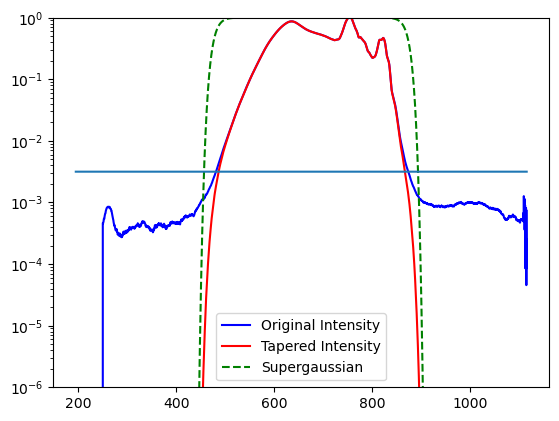

In [30]:
# CHANGE FILEINDEX TO EXECUTE FOR DIFFERENT SPECTRA
fileindex = 1

fileloc = FILES[fileindex]['fileloc']
center = FILES[fileindex]['center']
width = FILES[fileindex]['width']
order = FILES[fileindex]['order']
name = FILES[fileindex]['name']

# load and taper the data
df = pd.read_csv(fileloc)  
df['Intensity'] = scale_y_axis(df['Intensity'])

x = df['Wavelength(nm)'].values
y = df['Intensity'].values
df['Intensity'] = taper_with_supergaussian(x, y, center=center, width=width, order=order, amplitude=1) # replaces the noisy intensity with the tapered one, thereby eliminating noise from further use

plt.plot(x,y, label='Original Intensity', color='blue',)
plt.plot(x, df['Intensity'], label='Tapered Intensity', color='red')
plt.plot(x, supergaussian(x, center=center, width=width, order=order, amplitude=1), label='Supergaussian', color='green', linestyle='--')
plt.plot(x, np.full_like(y, pow(10, -2.5))) # horizontal line to denote the point till which a proper tapered is expected. Everything below this level is regarded as noise.
plt.yscale('log')
plt.ylim(1e-6, 1)
plt.legend()

In [31]:
"""Data available in DF format:
    Wavelength(nm) : the actual wavelength values
    Intensity : the intensity values at those wavelengths, but with noise removed by tapering
"""

def wavelength_to_frequency_data(df):
    """
    Convert the spectral data from wavelength to frequency domain, with Jacobian correction 
    Takes the original dataframe and returns a new dataframe with frequency and intensity.
    
    """
    
    # Convert wavelength (nm) to frequency (Hz)
    c = 3e8  # Speed of light in m/s
    wavelength_m = df['Wavelength(nm)'] * 1e-9  # Convert nm to meters
    frequency_hz = c / wavelength_m  # Frequency in Hz

    # Apply Jacobian correction: I(nu) = I(lambda) * (lambda^2 / c)
    # Intensity must be adjusted to conserve energy
    intensity_corrected = df['Intensity'] * (wavelength_m**2 / c)
    intensity_corrected = scale_y_axis(intensity_corrected)  # Scale to [0, 1] for visualization


    # Create frequency domain dataframe and sort by increasing frequency
    df_freq = pd.DataFrame({
    'Frequency(Hz)': frequency_hz,
    'Corrected Intensity': intensity_corrected
    }).sort_values(by='Frequency(Hz)')
    
    return df_freq

df_freq = wavelength_to_frequency_data(df)

/opt/homebrew/Caskroom/miniconda/base/envs/computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Original Spectrum : Frequency domain (shown in E=hf)')

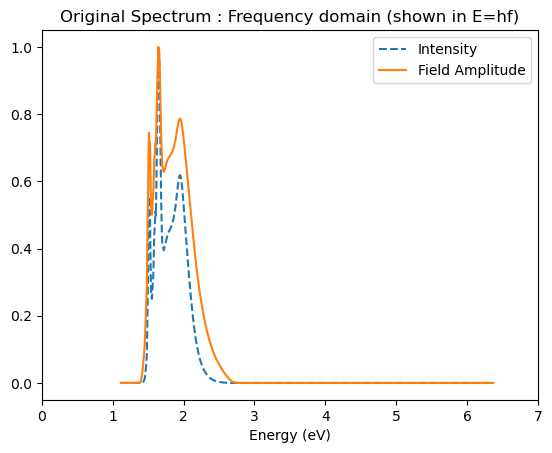

In [32]:
# Convert from intensity to field

# Field amplitude is the square root of intensity
# we take 0 phase considerations, so imag part is 0 for the complex field below
field_amplitude = np.sqrt(df_freq['Corrected Intensity']).astype(np.complex128)
frequency = df_freq['Frequency(Hz)'].values

plt.plot(frequency * 6.63e-34/1.6e-19, df_freq['Corrected Intensity'], label="Intensity", lw=1.5, linestyle="--")
plt.plot(frequency * 6.63e-34/1.6e-19, field_amplitude, label="Field Amplitude", lw=1.5)
# plt.plot(frequency, df_freq['Corrected Intensity'], label="Intensity", lw=1.5, linestyle="--")
plt.xlim(0, 7)
plt.legend()
plt.xlabel("Energy (eV)")
plt.title("Original Spectrum : Frequency domain (shown in E=hf)")

500


Text(0.5, 1.0, 'Spectrum : Padding added between Origin and original spectrum')

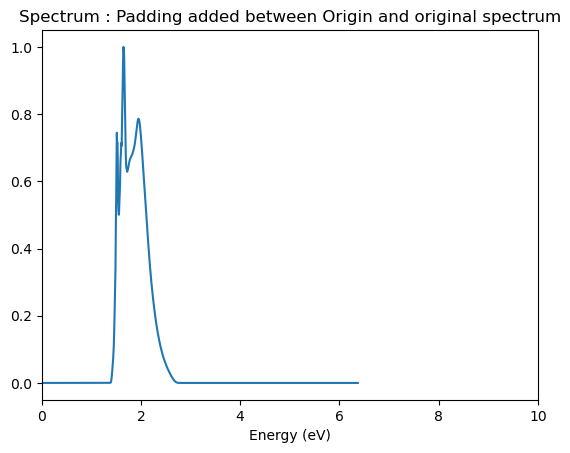

In [33]:
def stretch_axis_to_origin(frequency, field_amplitude):
    """
    Stretch the frequency axis to include the origin (0 Hz) by padding with zeros.
    
    Args:
        frequency (np.ndarray): Original frequency values.
        field_amplitude (np.ndarray): Corresponding field amplitude values.
        
    Returns:
        np.ndarray: Extended frequency array with zero-padding.
        np.ndarray: Extended field amplitude array with zero-padding.
    """
    min_freq = min(frequency)
    
    # Create a new frequency array that includes the target frequency
    padding_freq = np.linspace(0, min_freq*1, 500)
    padding_field_amplitude = np.zeros_like(padding_freq)
    
    print(len(padding_freq))
    
    # Concatenate padding frequency with original frequency, avoiding duplication of the last element
    extended_freq = np.concatenate((padding_freq[:-1], frequency))
    extended_field = np.concatenate((padding_field_amplitude[:-1], field_amplitude))
    
    return extended_freq, extended_field

extended_freq, extended_field = stretch_axis_to_origin(frequency, field_amplitude)

# plt.plot(extended_freq, extended_field, label="Extended Field Amplitude", lw=0.5, marker="*" ,color='black')
plt.plot(extended_freq * 6.63e-34/1.6e-19, extended_field, label="Field Amplitude", lw=1.5)
plt.xlim(0, 10)
# plt.plot(frequency, field_amplitude, label="Original Field Amplitude", marker="o" ,lw=2)
# plt.xlim(0.268e15, 0.27000e15)
# plt.ylim(-0.001, 0.005)
plt.xlabel("Energy (eV)")
plt.title("Spectrum : Padding added between Origin and original spectrum")


Text(0.5, 1.0, 'Spectrum : Padding added to the left (to increase time resolution post IFT)')

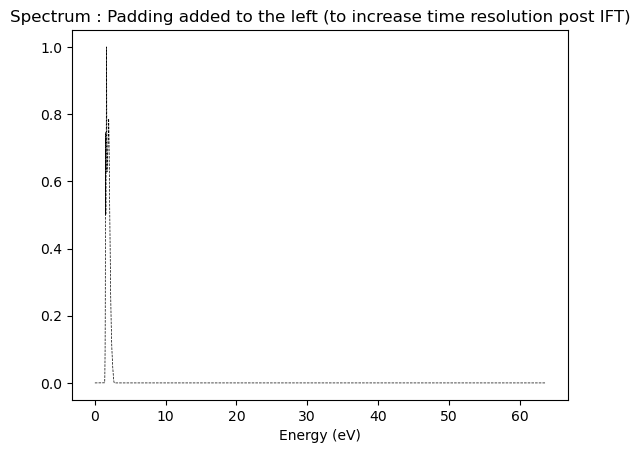

In [34]:
# function to add zero padding for temporal resolution

def add_zero_padding(frequency, field_amplitude, padding_factor=2):
    """
    Add zero padding to the frequency and field amplitude arrays for temporal resolution.

    Args:
        frequency (np.ndarray): Original frequency values.
        field_amplitude (np.ndarray): Corresponding field amplitude values.
        padding_factor (int): The factor by which to pad the arrays (default is 1). Padding factor increase the maximum frequency by this factor, and the length of the padded arrays will be increased by this factor.

    Returns:
        np.ndarray: Padded frequency array.
        np.ndarray: Padded field amplitude array.
    """
    
    max_freq = np.max(frequency)
    
    zero_padding_freq = np.linspace(max_freq,
                                max_freq * padding_factor, 
                                len(frequency) * padding_factor)  
    zero_padding_field_amplitude = np.zeros_like(zero_padding_freq)
    
    # Concatenate the original frequency and field amplitude with the zero padding
    padded_freq = np.concatenate((frequency, zero_padding_freq[1:]))  # Exclude the first element to avoid duplication
    padded_field_amplitude = np.concatenate((field_amplitude, zero_padding_field_amplitude[1:]))
    
    # plt.plot(frequency, field_amplitude+0.1, label="Original Field Amplitude", marker="o" ,lw=2
    #         )
    # plt.plot(zero_padding_freq[1:], zero_padding_field_amplitude[1:], label="Zero Padding", marker='*', color='red', lw=2)
    # plt.xlim(1.535e15, 1.540e15)
    
    
    return padded_freq, padded_field_amplitude


frequency, field = add_zero_padding(extended_freq, extended_field, padding_factor=10)
    
plt.plot(frequency* 6.63e-34/1.6e-19, field, label="Padded Field Amplitude", lw=0.5 ,color='black', linestyle='--')
plt.xlabel("Energy (eV)")
plt.title("Spectrum : Padding added to the left (to increase time resolution post IFT)")
# plt.xlim(0, 6)
# plt.ylim(-0.1, 0.1)
# print(frequency.shape, field.shape)
# # check for duplicate frequencies
# duplicates = np.where(np.diff(frequency) == 0)[0]
# if duplicates.size > 0:
#     print(f"Duplicate frequencies found at indices: {duplicates}")  
   

In [35]:
def interpolate_to_equidistant_grid(frequency, field_amplitude):
    """
    Interpolate the frequency and field amplitude data to an equidistant grid.

    Args:
        frequency (np.ndarray): Original frequency values.
        field_amplitude (np.ndarray): Corresponding field amplitude values.

    Returns:
        np.ndarray: Interpolated frequency array.
        np.ndarray: Interpolated field amplitude array.
    """
    # Create an interpolating function
    interp_func = interp1d(frequency, field_amplitude, kind='cubic')
    
    # Create a new frequency grid
    new_frequency = np.linspace(np.min(frequency), np.max(frequency), len(frequency))
    
    # Interpolate the field amplitude on the new frequency grid
    new_field_amplitude = interp_func(new_frequency)
    
    return new_frequency, new_field_amplitude

uniform_freq, uniform_field = interpolate_to_equidistant_grid(frequency, field)

# plt.plot(uniform_freq, uniform_field, label="Interpolated Field Amplitude", lw=0.5, marker="*" ,color='black')
# plt.xlim(0.268e15, 0.27000e15)

/var/folders/2c/v1gf79kx5qz4k9m6pz64n50c0000gn/T/ipykernel_18307/658123310.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  y = np.asarray(y, dtype=np.float64)


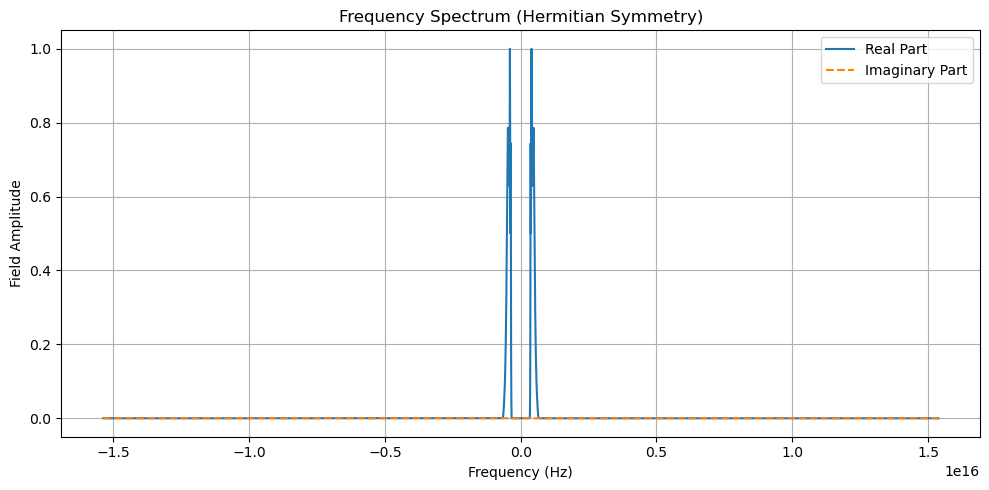

In [36]:
def mirror_frequency_axis(x, y):
    """
    Create a mirrored frequency axis and spectrum for FFT.

    Parameters:
        x (np.ndarray): Frequency array (positive only, uniformly spaced).
        y (np.ndarray): Intensity or field array.

    Returns:
        x_mirrored (np.ndarray): Symmetric frequency array (-f_max to +f_max).
        y_mirrored (np.ndarray): Hermitian-symmetric spectrum (conj mirror of y).
    """
    
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    
    if len(x) != len(y):
        raise ValueError("x and y must be the same length.")
    if not np.allclose(np.diff(x), np.diff(x)[0]):
        raise ValueError("Frequency axis must be uniformly spaced.")

    # Skip the DC term to avoid double-counting zero
    x_neg = -x[::-1][1:]
    y_neg = np.conj(y[::-1][1:])  # Hermitian symmetry

    x_mirrored = np.concatenate((x_neg, x))
    y_mirrored = np.concatenate((y_neg, y))

    return x_mirrored, y_mirrored

frequency_mirrored, field_mirrored = mirror_frequency_axis(uniform_freq, uniform_field)
field_mirrored = field_mirrored.astype(np.complex128)  # Construct real field spectrum (zero phase)

field_mirrored = field_mirrored.astype(np.complex128)  # Construct real field spectrum (zero phase)

plt.figure(figsize=(10, 5))
plt.plot(frequency_mirrored, field_mirrored.real, lw=1.5)
plt.plot(frequency_mirrored, field_mirrored.imag, lw=1.5, ls='--')
plt.title("Frequency Spectrum (Hermitian Symmetry)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Field Amplitude")
plt.grid(True)
plt.legend(['Real Part', 'Imaginary Part'])
plt.tight_layout()
plt.show()

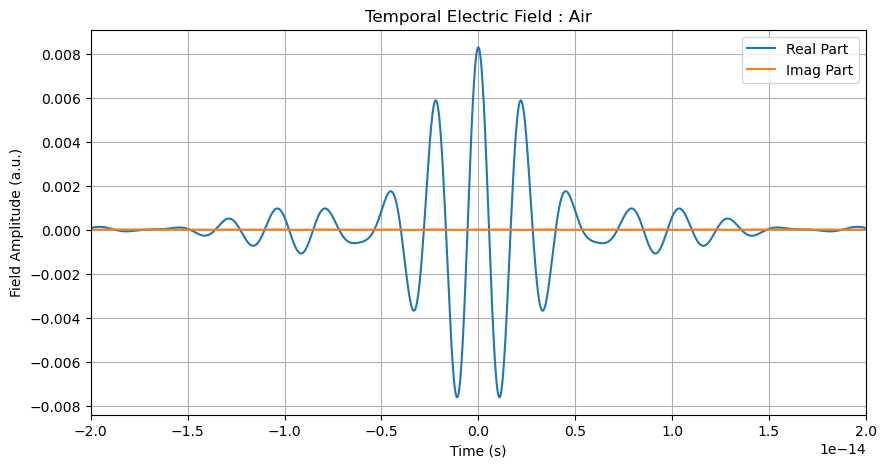

In [37]:
def perform_ifft(frequency, field):
    """
    Perform the Inverse Fast Fourier Transform (IFFT) on the given frequency and field data. Coefficients must be symmetric, ordering enforced in function.

    Args:
        frequency (np.ndarray): Frequency values (must be symmetric).
        field (np.ndarray): Field amplitude values (must be complex).

    Returns:
        np.ndarray: Time-domain signal obtained from IFFT.
    """
    # Ensure the input is complex
    field = field.astype(np.complex128)
    
    frequency_ordered = np.fft.ifftshift(frequency) # this is coefficients in the correct order for ifft, STRICTLY as they are obtained due from the FFT algorithm
    # This is NOT FOR VISUALIZATION !!!

    
    
    # Step 1: Reorder frequency components so 0 Hz is at index 0
    field_ordered = np.fft.ifftshift(field)

    # Step 2: IFFT to time domain (complex signal)
    field_time = np.fft.ifft(field_ordered)

    # Step 3: Create time axis
    df = frequency_mirrored[1] - frequency_mirrored[0]  # frequency resolution
    T = 1 / df                                          # total time span
    N = len(field_mirrored)                             # number of points
    dt = T / N                                          # time resolution
    time = np.fft.fftshift(np.fft.fftfreq(N, d=df))     # centered time axis
    field_time_shifted = np.fft.fftshift(field_time)    # shift signal for plotting

    return time, field_time_shifted


time, field_time_shifted = perform_ifft(frequency_mirrored, field_mirrored)


# Step 4: Plot time-domain field
plt.figure(figsize=(10, 5))
plt.plot(time, np.real(field_time_shifted), label='Real Part', )
plt.plot(time, np.imag(field_time_shifted), label='Imag Part')
plt.title(f"Temporal Electric Field : {name}")
plt.xlabel("Time (s)")
plt.ylabel("Field Amplitude (a.u.)")
plt.xlim(-20e-15, 20e-15)
plt.grid(True)
plt.legend()
    
plt.savefig(f"{name}_Temporal_Field.png", dpi=300, bbox_inches='tight')  # Save before show
plt.show()

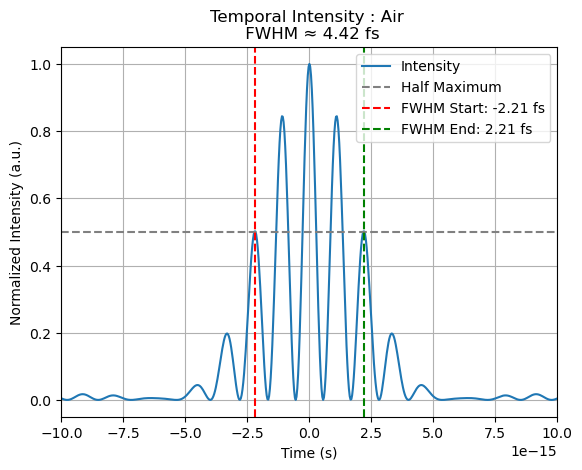

In [38]:
def compute_fwhm(t, intensity):
    intensity = intensity / np.max(intensity)
    half_max = 0.5
    indices = np.where(intensity >= half_max)[0]

    if len(indices) < 2:
        return None  # FWHM not well-defined

    t1 = t[indices[0]]
    t2 = t[indices[-1]]
    return t1, t2


# ---------------------------
# 7. Plot Temporal Profile, with FWHM
# ---------------------------
intensity = np.abs(field_time_shifted)**2
intensity = scale_y_axis(intensity)

plt.plot(time, intensity, label='Intensity', lw=1.5)
plt.xlim(-30e-15, 30e-15)

t1, t2 = compute_fwhm(time, intensity)
fwhm = t2-t1

plt.axhline(0.5, color='gray', linestyle='--', label='Half Maximum')
plt.axvline(t1, color='red', linestyle='--', label=f'FWHM Start: {t1/1e-15:.2f} fs')
plt.axvline(t2, color='green', linestyle='--', label=f'FWHM End: {t2/1e-15:.2f} fs')
plt.title(f'Temporal Intensity : {name} \n FWHM ≈ {fwhm/1e-15:.2f} fs')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Intensity (a.u.)')
plt.legend()
plt.xlim(-10e-15, 10e-15)
plt.grid(True)


plt.savefig(f"{name}_Temporal_Intensity.png", dpi=300, bbox_inches='tight')  # Save before show
plt.show()

In [39]:
field_time_shifted

array([-3.69304775e-14-2.14490060e-09j, -3.31722453e-13-6.42208754e-09j,
       -9.17836312e-13-1.06614869e-08j, ...,
       -9.17836151e-13+1.06614869e-08j, -3.31722484e-13+6.42208754e-09j,
       -3.69304686e-14+2.14490060e-09j], shape=(91231,))

In [ ]:
from scipy.signal import hilbert

field_t = np.real(field_time_shifted.copy())
t = time.copy()

# Step 1: Compute analytic signal
analytic_signal = hilbert(field_t)

# Step 2: Envelope is magnitude of the analytic signal
envelope = np.abs(analytic_signal)

# Step 3 (Optional): Normalize if needed
envelope /= np.max(envelope)

# Step 4: Plot the results
plt.figure(figsize=(8, 5))
plt.plot(t, field_t, label='Electric Field E(t)', alpha=0.6)
plt.plot(t, envelope, label='Envelope |E(t)| (Hilbert)', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Temporal Envelope using Hilbert Transform')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 't' is not defined

<Figure size 800x500 with 0 Axes>